# Architectures of Deep Neural Networks
## A Comparative Overview

**MAT 4953 / MAT 6973 — Mathematical Foundations of AI** (Spring 2026, UTSA)

---

This notebook provides a broad, side-by-side survey of the major deep neural network architecture families:

1. **Feedforward Networks (MLPs)** — the baseline: layers of affine maps composed with pointwise nonlinearities.
2. **Convolutional Neural Networks (CNNs)** — exploiting spatial structure through local connectivity and weight sharing.
3. **Recurrent / Recursive Neural Networks (RNNs)** — processing sequential data with hidden-state feedback loops.
4. **Transformers** — replacing recurrence with self-attention and positional encoding.
5. **Autoencoders & Generative Models** — learning compressed representations and generating new data.

For each architecture we discuss the *graph topology* (the directed acyclic — or cyclic — computational graph), the mathematical formulation of the forward pass, the class of tasks it naturally addresses, and its computational profile (memory, FLOPs, parallelizability). Interactive **toy examples** with adjustable parameters let you build intuition before we dive deeper into each architecture in subsequent lessons.

---
# 0. Setup

**Local version** — this notebook is configured to run in a local Jupyter environment. It uses only NumPy, Matplotlib, and Keras (with a JAX backend). See the repository's `requirements.txt`.

In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import cm
from IPython.display import display, HTML

import keras
from keras import layers, ops

%matplotlib inline

# Reproducibility
np.random.seed(42)

print(f"Keras version: {keras.__version__}")
print(f"Keras backend: {keras.backend.backend()}")

Keras version: 3.13.2
Keras backend: jax


## Helper functions for architecture diagrams

We define a small utility to draw schematic diagrams of each architecture's computational graph directly in Matplotlib. These are *not* full network visualizations — they are deliberately simplified to highlight the **topological differences** between architectures.

In [ ]:
def draw_layer_graph(ax, layers_spec, title="", connections="dense"):
    # Simple node-and-edge diagram (used for the overview comparison in Section 1)
    n_layers = len(layers_spec)
    x_positions = np.linspace(0, 1, n_layers)
    node_coords = []
    for li, (x, n) in enumerate(zip(x_positions, layers_spec)):
        ys = np.linspace(0.15, 0.85, n) if n > 1 else [0.5]
        coords = [(x, y) for y in ys]
        node_coords.append(coords)

    for li in range(n_layers - 1):
        src = node_coords[li]
        tgt = node_coords[li + 1]
        if connections == "conv":
            for j, (tx, ty) in enumerate(tgt):
                n_src = len(src)
                center = int(j * n_src / len(tgt))
                for di in range(-1, 2):
                    idx = center + di
                    if 0 <= idx < n_src:
                        sx, sy = src[idx]
                        ax.plot([sx, tx], [sy, ty], 'k-', alpha=0.25, linewidth=0.8)
        else:
            for sx, sy in src:
                for tx, ty in tgt:
                    ax.plot([sx, tx], [sy, ty], 'k-', alpha=0.15, linewidth=0.8)

    if connections == "recurrent" and n_layers >= 2:
        for li in range(1, n_layers - 1):
            for (nx, ny) in node_coords[li]:
                arc = mpatches.FancyArrowPatch(
                    (nx, ny + 0.04), (nx + 0.02, ny + 0.04),
                    connectionstyle="arc3,rad=-0.6",
                    arrowstyle='->', mutation_scale=10,
                    color='crimson', linewidth=1.5)
                ax.add_patch(arc)

    if connections == "skip" and n_layers >= 3:
        sx, sy = node_coords[0][len(node_coords[0])//2]
        tx, ty = node_coords[-1][len(node_coords[-1])//2]
        ax.annotate("", xy=(tx, ty + 0.03), xytext=(sx, sy + 0.03),
                     arrowprops=dict(arrowstyle="->", color="dodgerblue",
                                     lw=2, connectionstyle="arc3,rad=-0.3"))

    colors = plt.cm.Set2(np.linspace(0, 1, n_layers))
    for li, coords in enumerate(node_coords):
        for (nx, ny) in coords:
            ax.plot(nx, ny, 'o', markersize=10, color=colors[li],
                    markeredgecolor='k', markeredgewidth=0.5)

    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')


def draw_arch_graph(ax, node_positions, edges, title="",
                     node_colors=None, node_labels=None,
                     self_loops=None, skip_edges=None,
                     node_size=300, font_size=7):
    # Draw regular edges
    for e in edges:
        src, dst = e[0], e[1]
        style = e[2] if len(e) > 2 else {}
        color = style.get('color', '#888888')
        alpha = style.get('alpha', 0.35)
        lw = style.get('lw', 1.0)
        x0, y0 = node_positions[src]
        x1, y1 = node_positions[dst]
        ax.plot([x0, x1], [y0, y1], color=color, alpha=alpha,
                linewidth=lw, zorder=1)

    # Skip / residual connections
    if skip_edges:
        for src, dst, style in skip_edges:
            x0, y0 = node_positions[src]
            x1, y1 = node_positions[dst]
            rad = style.get('rad', -0.3)
            color = style.get('color', 'dodgerblue')
            lw = style.get('lw', 2.0)
            ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                        arrowprops=dict(arrowstyle="->", color=color,
                                        lw=lw, connectionstyle=f"arc3,rad={rad}"),
                        zorder=2)

    # Self-loops
    if self_loops:
        for nid in self_loops:
            nx, ny = node_positions[nid]
            arc = mpatches.FancyArrowPatch(
                (nx - 0.02, ny + 0.06), (nx + 0.02, ny + 0.06),
                connectionstyle="arc3,rad=-0.8",
                arrowstyle='->', mutation_scale=12,
                color='crimson', linewidth=2, zorder=3)
            ax.add_patch(arc)

    # Nodes
    for nid, (nx, ny) in node_positions.items():
        c = '#a8d8ea'
        if node_colors and nid in node_colors:
            c = node_colors[nid]
        ax.plot(nx, ny, 'o', markersize=14, color=c,
                markeredgecolor='k', markeredgewidth=0.8, zorder=4)
        if node_labels and nid in node_labels:
            ax.text(nx, ny, node_labels[nid], ha='center', va='center',
                    fontsize=font_size, fontweight='bold', zorder=5)

    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_aspect('equal')
    ax.axis('off')


def layer_positions(layer_sizes, x_coords=None, y_range=(0.1, 0.9)):
    positions = {}
    ids_by_layer = []
    if x_coords is None:
        x_coords = np.linspace(0, 1, len(layer_sizes))
    node_id = 0
    for li, (x, n) in enumerate(zip(x_coords, layer_sizes)):
        ys = np.linspace(y_range[0], y_range[1], n) if n > 1 else [0.5]
        layer_ids = []
        for y in ys:
            positions[node_id] = (x, y)
            layer_ids.append(node_id)
            node_id += 1
        ids_by_layer.append(layer_ids)
    return positions, ids_by_layer


def dense_edges(ids_by_layer, style=None):
    if style is None:
        style = {}
    edges = []
    for li in range(len(ids_by_layer) - 1):
        for s in ids_by_layer[li]:
            for t in ids_by_layer[li + 1]:
                edges.append((s, t, style))
    return edges


def local_edges(ids_by_layer, receptive_field=3, style=None):
    if style is None:
        style = {}
    edges = []
    for li in range(len(ids_by_layer) - 1):
        src_ids = ids_by_layer[li]
        tgt_ids = ids_by_layer[li + 1]
        n_src = len(src_ids)
        n_tgt = len(tgt_ids)
        half = receptive_field // 2
        for j, tid in enumerate(tgt_ids):
            center = int(j * n_src / n_tgt)
            for di in range(-half, half + 1):
                idx = center + di
                if 0 <= idx < n_src:
                    edges.append((src_ids[idx], tid, style))
    return edges

print("Architecture graph utilities loaded.")

---
# 1. Architecture Topologies at a Glance

Before diving into the mathematics, let us compare the **computational graph** of each architecture family. The topology of the graph — how nodes (neurons) are connected to one another — is the single most important structural distinction.

| Architecture | Graph type | Key structural property |
|---|---|---|
| **Feedforward (MLP)** | DAG, fully connected layers | No weight sharing, no cycles |
| **CNN** | DAG, locally connected + weight sharing | Translation equivariance via shared kernels |
| **RNN** | Cyclic (or unrolled DAG) | Hidden state feeds back; weight sharing across time |
| **Transformer** | DAG, fully connected attention | All-to-all token interactions via attention weights |
| **Autoencoder** | DAG, bottleneck topology | Encoder compresses, decoder reconstructs |

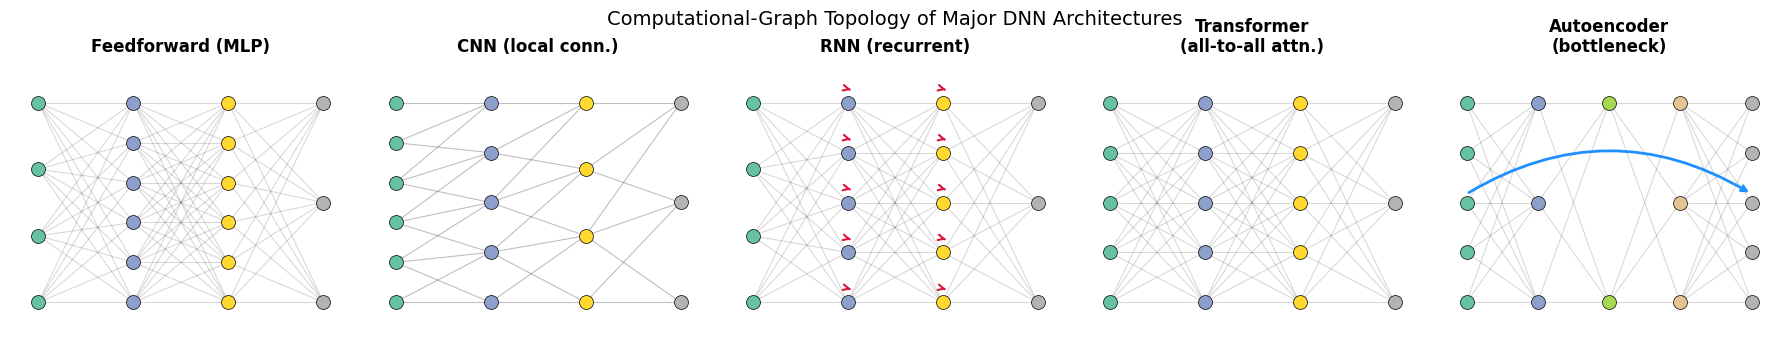

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))

draw_layer_graph(axes[0], [4, 6, 6, 3], title="Feedforward (MLP)", connections="dense")
draw_layer_graph(axes[1], [6, 5, 4, 3], title="CNN (local conn.)", connections="conv")
draw_layer_graph(axes[2], [4, 5, 5, 3], title="RNN (recurrent)", connections="recurrent")
draw_layer_graph(axes[3], [5, 5, 5, 3], title="Transformer\n(all-to-all attn.)", connections="dense")
draw_layer_graph(axes[4], [5, 3, 2, 3, 5], title="Autoencoder\n(bottleneck)", connections="skip")

plt.tight_layout()
plt.suptitle("Computational-Graph Topology of Major DNN Architectures", fontsize=14, y=1.04)
plt.show()

---
# 2. Feedforward Neural Networks (MLPs)

## 2.1 Mathematical formulation

A feedforward network with $L$ layers computes a function $f: \mathbb{R}^{d_0} \to \mathbb{R}^{d_L}$ by the composition

$$\mathbf{h}^{(0)} = \mathbf{x}, \qquad \mathbf{h}^{(\ell)} = \sigma\!\bigl(W^{(\ell)}\,\mathbf{h}^{(\ell-1)} + \mathbf{b}^{(\ell)}\bigr), \quad \ell = 1, \dots, L,$$

where $W^{(\ell)} \in \mathbb{R}^{d_\ell \times d_{\ell-1}}$ is the weight matrix, $\mathbf{b}^{(\ell)} \in \mathbb{R}^{d_\ell}$ is the bias vector, and $\sigma$ is a nonlinear activation (ReLU, tanh, etc.). The output is $\hat{\mathbf{y}} = \mathbf{h}^{(L)}$.

**Graph topology:** The computational graph is a *directed acyclic graph (DAG)* arranged in layers, with every node in layer $\ell-1$ connected to every node in layer $\ell$ (hence "fully connected" or "dense"). There is no weight sharing: each edge carries a unique parameter.

**Parameter count:** For a network with layer widths $(d_0, d_1, \dots, d_L)$, the total number of parameters is

$$P = \sum_{\ell=1}^{L} d_\ell\,(d_{\ell-1} + 1).$$

## 2.3 Toy example: learning XOR

The XOR function $\{0,1\}^2 \to \{0,1\}$ is the classic example of a function that is *not* linearly separable. A single-layer perceptron cannot learn it. We train a small MLP and visualize the learned decision boundary.

## 2.2 Graph structure

The diagram below shows a feedforward network with layer widths (4, 6, 6, 3). Every node in each layer is connected to every node in the next layer (fully connected / dense). The graph is a DAG with **no cycles and no weight sharing**: each edge represents a unique learnable parameter.

In [ ]:
# --- Feedforward (MLP) graph ---
fig, ax = plt.subplots(figsize=(8, 5))

sizes_ff = [4, 6, 6, 3]
pos_ff, layers_ff = layer_positions(sizes_ff)
edges_ff = dense_edges(layers_ff)

colors_ff = {}
layer_colors = ['#f9e79f', '#aed6f1', '#aed6f1', '#abebc6']
layer_names = ['Input', 'Hidden 1', 'Hidden 2', 'Output']
for li, ids in enumerate(layers_ff):
    for nid in ids:
        colors_ff[nid] = layer_colors[li]

draw_arch_graph(ax, pos_ff, edges_ff, title="Feedforward Network (MLP)",
                node_colors=colors_ff)

for li, x in enumerate(np.linspace(0, 1, len(sizes_ff))):
    ax.text(x, -0.05, layer_names[li], ha='center', fontsize=10, style='italic')

ax.set_xlim(-0.15, 1.15)
ax.set_ylim(-0.15, 1.05)
plt.tight_layout()
plt.show()

In [4]:
# Generate XOR data (with some noise for visual interest)
n_samples = 400
X_xor = np.random.uniform(0, 1, (n_samples, 2))
y_xor = ((X_xor[:, 0] > 0.5) ^ (X_xor[:, 1] > 0.5)).astype(np.float32)

# Build a small MLP
hidden_units = 16   # @param {type: "integer"} -- try 2, 4, 8, 16, 32
n_epochs_mlp = 100  # @param {type: "integer"}

model_mlp = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(hidden_units, activation="relu"),
    layers.Dense(hidden_units, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])
model_mlp.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history_mlp = model_mlp.fit(X_xor, y_xor, epochs=n_epochs_mlp, batch_size=32, verbose=0)

print(f"Final accuracy: {history_mlp.history['accuracy'][-1]:.3f}")
print(f"Parameters: {model_mlp.count_params()}")

W0000 00:00:1775083775.249908 23275712 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1775083775.272027 23275712 service.cc:145] XLA service 0x139c314a0 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775083775.272197 23275712 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1775083775.276100 23275712 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1775083775.276116 23275712 mps_client.cc:384] XLA backend will use up to 11452858368 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M1 Pro

systemMemory: 16.00 GB
maxCacheSize: 5.33 GB



/Users/eduenez/repos/MathAIspring2026UTSA/.venv/lib/python3.12/site-packages/jax/_src/interpreters/mlir.py:1130: UserWarning: Some donated buffers were not usable: ShapedArray(float32[2,16]), ShapedArray(float32[16]), ShapedArray(float32[16,16]), ShapedArray(float32[16]), ShapedArray(float32[16,1]), ShapedArray(float32[1]), ShapedArray(int32[]), ShapedArray(float32[]), ShapedArray(float32[2,16]), ShapedArray(float32[2,16]), ShapedArray(float32[16]), ShapedArray(float32[16]), ShapedArray(float32[16,16]), ShapedArray(float32[16,16]), ShapedArray(float32[16]), ShapedArray(float32[16]), ShapedArray(float32[16,1]), ShapedArray(float32[16,1]), ShapedArray(float32[1]), ShapedArray(float32[1]), ShapedArray(float32[]), ShapedArray(float32[]), ShapedArray(float32[]), ShapedArray(float32[]).
Donation is not implemented for ('METAL',).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"
/Users/eduenez/repos/Ma

Final accuracy: 0.863
Parameters: 337


/Users/eduenez/repos/MathAIspring2026UTSA/.venv/lib/python3.12/site-packages/jax/_src/interpreters/mlir.py:1130: UserWarning: Some donated buffers were not usable: ShapedArray(float32[2,16]), ShapedArray(float32[16]), ShapedArray(float32[16,16]), ShapedArray(float32[16]), ShapedArray(float32[16,1]), ShapedArray(float32[1]).
Donation is not implemented for ('METAL',).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


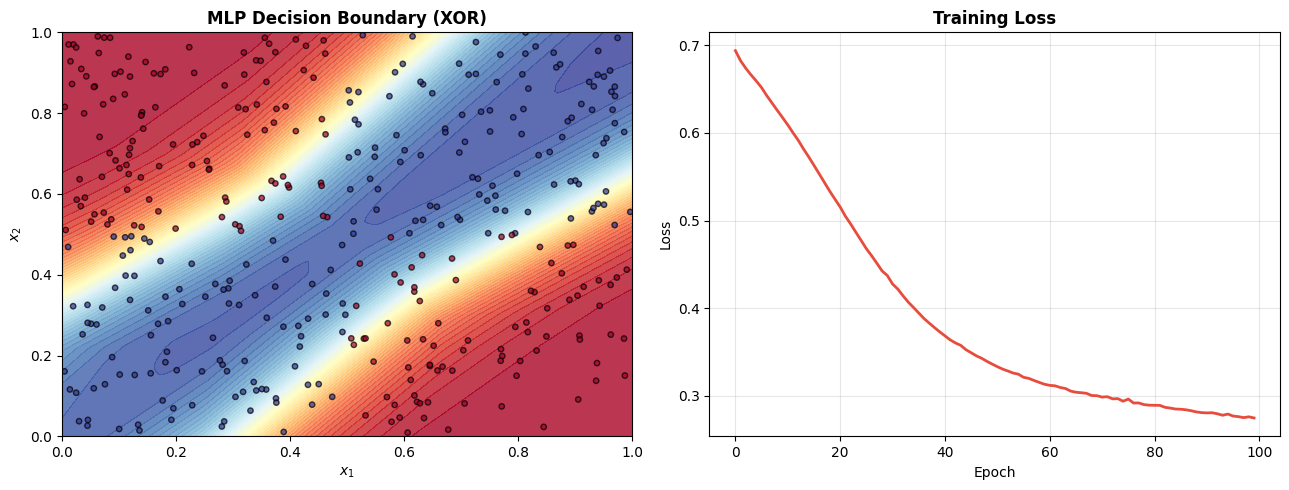

In [5]:
# Visualize the learned decision boundary
xx, yy = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
preds = np.array(model_mlp.predict(grid, verbose=0)).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Decision boundary
axes[0].contourf(xx, yy, preds, levels=50, cmap='RdYlBu_r', alpha=0.8)
axes[0].scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, cmap='RdYlBu_r',
                edgecolors='k', s=15, alpha=0.7)
axes[0].set_title("MLP Decision Boundary (XOR)", fontweight='bold')
axes[0].set_xlabel("$x_1$"); axes[0].set_ylabel("$x_2$")

# Training curve
axes[1].plot(history_mlp.history['loss'], color='#e74c3c', linewidth=2)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].set_title("Training Loss", fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Experiment:** Try changing `hidden_units` above (e.g., 2, 4, 8, 32). With only 2 hidden units in each layer, can the network still learn XOR? What is the minimum number of parameters needed? How does the decision boundary's smoothness change with network width?

---
# 3. Convolutional Neural Networks (CNNs)

## 3.1 Mathematical formulation

A 1-D convolutional layer with kernel size $k$ and $C_\text{out}$ output channels computes

$$h^{(\ell)}_{c,i} = \sigma\!\Biggl(\sum_{c'=1}^{C_\text{in}} \sum_{j=0}^{k-1} w^{(\ell)}_{c,c',j}\;\; h^{(\ell-1)}_{c',\,i+j} \;+\; b^{(\ell)}_c\Biggr),$$

where $i$ is the spatial index and $c$ the channel index.

**Key properties:**

- **Local connectivity:** Each output unit depends on only $k$ neighboring inputs (the *receptive field*), not on all inputs as in an MLP.
- **Weight sharing:** The same kernel weights $w_{c,c',j}$ are applied at every spatial position $i$. This makes the layer *translation equivariant*: shifting the input shifts the output by the same amount.
- **Parameter efficiency:** A convolutional layer with $C_\text{in}$ input channels, $C_\text{out}$ output channels, and kernel size $k$ has only $C_\text{out} \times (C_\text{in} \times k + 1)$ parameters, independent of the spatial dimension.

## 3.3 Toy example: detecting a pattern in a 1-D signal

We train a tiny 1-D CNN to detect whether a short "bump" pattern is present anywhere in a noisy signal. This illustrates translation equivariance: the network does not care *where* the bump is.

## 3.2 Graph structure

The CNN graph shows **local connectivity**: each node in layer $\ell$ connects only to a small neighborhood (the *receptive field*) in layer $\ell-1$. The colored edges indicate **shared weights**: the same kernel (same color) is applied at every spatial position. This is what makes CNNs translation-equivariant and parameter-efficient.

In [ ]:
# --- CNN graph with local connectivity and weight-sharing annotation ---
fig, ax = plt.subplots(figsize=(9, 5))

sizes_cnn = [8, 8, 6, 4, 2]
pos_cnn, layers_cnn = layer_positions(sizes_cnn, y_range=(0.05, 0.95))

kernel_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
edges_cnn = []
for li in range(len(layers_cnn) - 1):
    src_ids = layers_cnn[li]
    tgt_ids = layers_cnn[li + 1]
    n_src, n_tgt = len(src_ids), len(tgt_ids)
    rf = 3
    half = rf // 2
    for j, tid in enumerate(tgt_ids):
        center = int(j * n_src / n_tgt)
        for di_idx, di in enumerate(range(-half, half + 1)):
            idx = center + di
            if 0 <= idx < n_src:
                c = kernel_colors[di_idx % len(kernel_colors)]
                edges_cnn.append((src_ids[idx], tid,
                                  {'color': c, 'alpha': 0.6, 'lw': 1.5}))

layer_cols_cnn = ['#f9e79f', '#aed6f1', '#aed6f1', '#d5f5e3', '#abebc6']
colors_cnn = {}
for li, ids in enumerate(layers_cnn):
    for nid in ids:
        colors_cnn[nid] = layer_cols_cnn[li]

draw_arch_graph(ax, pos_cnn, edges_cnn, title="Convolutional Neural Network (CNN)",
                node_colors=colors_cnn)

labels_cnn = ['Input\n(8 units)', 'Conv\n(k=3)', 'Conv\n(k=3)', 'Pool', 'Output']
for li, x in enumerate(np.linspace(0, 1, len(sizes_cnn))):
    ax.text(x, -0.08, labels_cnn[li], ha='center', fontsize=9, style='italic')

from matplotlib.lines import Line2D
legend_lines = [Line2D([0], [0], color=kernel_colors[i], lw=2, label=f'Kernel pos {i}')
                for i in range(3)]
ax.legend(handles=legend_lines, loc='upper right', fontsize=8,
          title='Shared weights', title_fontsize=9)

ax.set_xlim(-0.12, 1.18)
ax.set_ylim(-0.18, 1.1)
plt.tight_layout()
plt.show()

In [6]:
# Generate synthetic 1-D signals with/without a bump pattern
signal_length = 64
n_train = 1000
bump = np.array([0, 0.5, 1.0, 1.0, 0.5, 0], dtype=np.float32)

def make_data(n):
    X = np.random.randn(n, signal_length, 1).astype(np.float32) * 0.3
    y = np.zeros(n, dtype=np.float32)
    for i in range(n):
        if np.random.rand() > 0.5:
            pos = np.random.randint(0, signal_length - len(bump))
            X[i, pos:pos+len(bump), 0] += bump
            y[i] = 1.0
    return X, y

X_cnn, y_cnn = make_data(n_train)
X_cnn_test, y_cnn_test = make_data(300)

# Build a small 1-D CNN
kernel_size = 5       # @param {type: "integer"} -- try 3, 5, 7, 11
n_filters = 8         # @param {type: "integer"} -- try 4, 8, 16
n_epochs_cnn = 20     # @param {type: "integer"}

model_cnn = keras.Sequential([
    layers.Input(shape=(signal_length, 1)),
    layers.Conv1D(n_filters, kernel_size, activation="relu", padding="same"),
    layers.GlobalMaxPooling1D(),
    layers.Dense(1, activation="sigmoid"),
])
model_cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history_cnn = model_cnn.fit(X_cnn, y_cnn, epochs=n_epochs_cnn, batch_size=32,
                             validation_data=(X_cnn_test, y_cnn_test), verbose=0)

print(f"Test accuracy: {history_cnn.history['val_accuracy'][-1]:.3f}")
print(f"Parameters: {model_cnn.count_params()}")

/Users/eduenez/repos/MathAIspring2026UTSA/.venv/lib/python3.12/site-packages/jax/_src/interpreters/mlir.py:1130: UserWarning: Some donated buffers were not usable: ShapedArray(float32[5,1,8]), ShapedArray(float32[8]), ShapedArray(float32[8,1]), ShapedArray(float32[1]), ShapedArray(int32[]), ShapedArray(float32[]), ShapedArray(float32[5,1,8]), ShapedArray(float32[5,1,8]), ShapedArray(float32[8]), ShapedArray(float32[8]), ShapedArray(float32[8,1]), ShapedArray(float32[8,1]), ShapedArray(float32[1]), ShapedArray(float32[1]), ShapedArray(float32[]), ShapedArray(float32[]), ShapedArray(float32[]), ShapedArray(float32[]).
Donation is not implemented for ('METAL',).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"
/Users/eduenez/repos/MathAIspring2026UTSA/.venv/lib/python3.12/site-packages/jax/_src/interpreters/mlir.py:1130: UserWarning: Some donated buffers were not usable: ShapedArray(float32[5,1,8])

Test accuracy: 0.993
Parameters: 57


/Users/eduenez/repos/MathAIspring2026UTSA/.venv/lib/python3.12/site-packages/jax/_src/interpreters/mlir.py:1130: UserWarning: Some donated buffers were not usable: ShapedArray(float32[5,1,8]), ShapedArray(float32[8]), ShapedArray(float32[8,1]), ShapedArray(float32[1]).
Donation is not implemented for ('METAL',).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


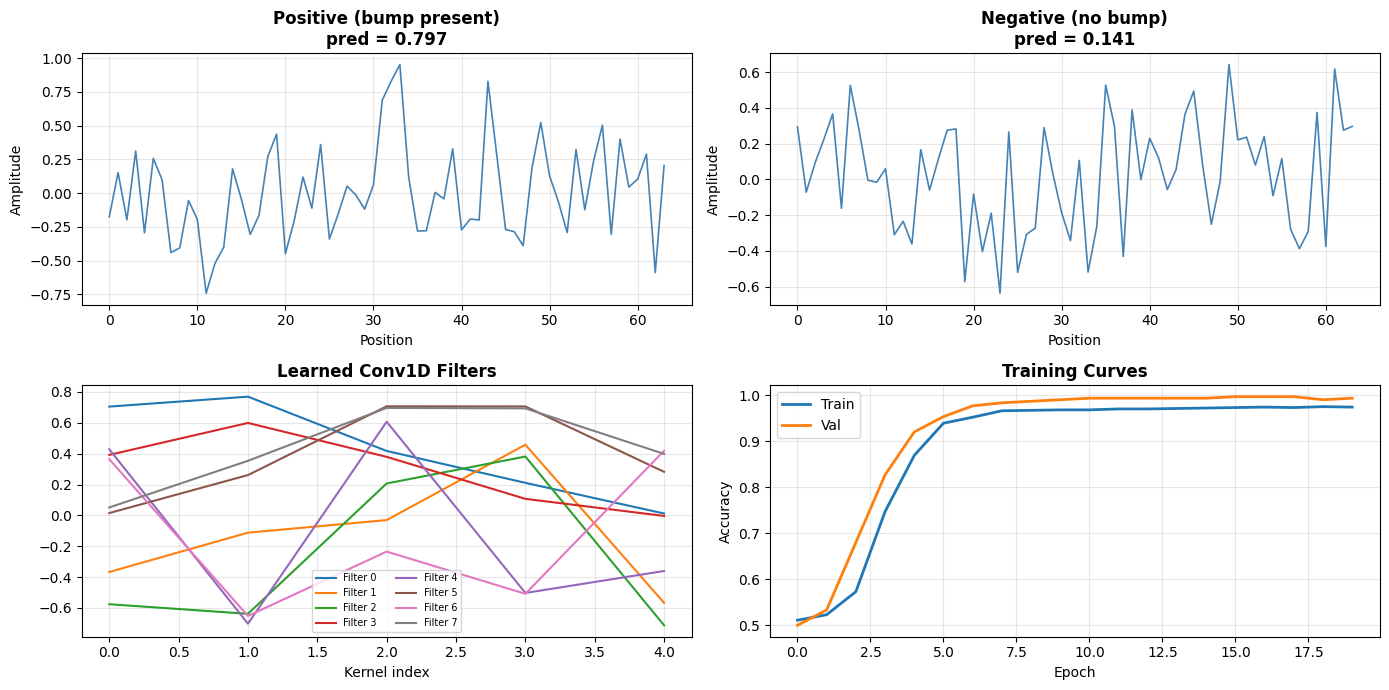

In [7]:
# Visualize: sample signals and learned convolutional filters
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

for idx, label in [(0, "Positive (bump present)"), (1, "Negative (no bump)")]:
    i = np.where(y_cnn_test == (1 - idx))[0][0]
    axes[0, idx].plot(X_cnn_test[i, :, 0], color='steelblue', linewidth=1.2)
    pred = float(np.array(model_cnn.predict(X_cnn_test[i:i+1], verbose=0))[0, 0])
    axes[0, idx].set_title(f"{label}\npred = {pred:.3f}", fontweight='bold')
    axes[0, idx].set_xlabel("Position"); axes[0, idx].set_ylabel("Amplitude")
    axes[0, idx].grid(True, alpha=0.3)

# Learned filters
conv_weights = np.array(model_cnn.layers[0].get_weights()[0])
for f in range(min(n_filters, 8)):
    axes[1, 0].plot(conv_weights[:, 0, f], label=f"Filter {f}", linewidth=1.5)
axes[1, 0].set_title("Learned Conv1D Filters", fontweight='bold')
axes[1, 0].set_xlabel("Kernel index"); axes[1, 0].legend(fontsize=7, ncol=2)
axes[1, 0].grid(True, alpha=0.3)

# Training curves
axes[1, 1].plot(history_cnn.history['accuracy'], label='Train', linewidth=2)
axes[1, 1].plot(history_cnn.history['val_accuracy'], label='Val', linewidth=2)
axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].set_title("Training Curves", fontweight='bold')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Experiment:** Try changing `kernel_size` and `n_filters`.

- What happens when the kernel is *smaller* than the bump pattern (e.g., `kernel_size = 3`)? Can the network still detect it?
- What if `n_filters = 1`? Is a single filter sufficient for this binary classification task?
- Compare the parameter count of this CNN with an MLP of similar accuracy on this task. Which is more parameter-efficient, and why?

---
# 4. Recurrent Neural Networks (RNNs)

## 4.1 Mathematical formulation

A simple (Elman) RNN processes a sequence $(\mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_T)$ by maintaining a hidden state $\mathbf{h}_t$ that evolves as

$$\mathbf{h}_t = \sigma\!\bigl(W_h\,\mathbf{h}_{t-1} + W_x\,\mathbf{x}_t + \mathbf{b}\bigr), \qquad \mathbf{h}_0 = \mathbf{0},$$

where $W_h \in \mathbb{R}^{d_h \times d_h}$ and $W_x \in \mathbb{R}^{d_h \times d_x}$ are weight matrices *shared across all time steps*. The final output can be read from $\mathbf{h}_T$ (for sequence-to-one tasks) or from the full sequence $(\mathbf{h}_1, \dots, \mathbf{h}_T)$.

**Graph topology:** The computational graph contains a *cycle*: the hidden state feeds back into itself. When "unrolled" over $T$ time steps, this becomes a very deep DAG with $T$ copies of the same weight matrices, which is why RNNs suffer from **vanishing/exploding gradients** for long sequences.

**Parameter count:** Only $d_h(d_h + d_x + 1)$, independent of the sequence length $T$. The same weights are reused at every time step.

## 4.3 Toy example: learning to sum a sequence

We ask a simple RNN to predict the *running sum* of a binary sequence (0s and 1s). This requires the network to maintain a "counter" in its hidden state: a natural test of sequential memory.

## 4.2 Graph structure

The RNN graph has two key features. On the left we show the **folded** (cyclic) view: the hidden layer has a self-loop representing the recurrence $\mathbf{h}_t \to \mathbf{h}_{t+1}$. On the right we show the **unrolled** view over $T=4$ time steps: the same weight matrices $W_h$ (red) and $W_x$ (blue) are reused at every step, creating a very deep DAG that makes backpropagation through time (BPTT) prone to vanishing gradients.

In [ ]:
# --- RNN graph: folded (cyclic) and unrolled views ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ---- Folded view (left) ----
ax = axes[0]
pos_folded = {
    'x': (0.0, 0.5),
    'h': (0.5, 0.5),
    'y': (1.0, 0.5),
}
edges_folded = [
    ('x', 'h', {'color': '#3498db', 'alpha': 0.7, 'lw': 2.5}),
    ('h', 'y', {'color': '#2ecc71', 'alpha': 0.7, 'lw': 2.5}),
]
colors_folded = {'x': '#f9e79f', 'h': '#aed6f1', 'y': '#abebc6'}
labels_folded = {'x': '$\\mathbf{x}_t$', 'h': '$\\mathbf{h}_t$', 'y': '$\\hat{y}_t$'}
draw_arch_graph(ax, pos_folded, edges_folded,
                title="RNN: Folded (Cyclic) View",
                node_colors=colors_folded, node_labels=labels_folded,
                self_loops=['h'], node_size=400, font_size=10)
ax.text(0.22, 0.58, '$W_x$', fontsize=11, color='#3498db', fontweight='bold')
ax.text(0.75, 0.58, '$W_y$', fontsize=11, color='#2ecc71', fontweight='bold')
ax.text(0.50, 0.72, '$W_h$', fontsize=11, color='crimson', fontweight='bold')
ax.set_xlim(-0.2, 1.2); ax.set_ylim(-0.1, 1.0)

# ---- Unrolled view (right) ----
ax = axes[1]
T_unroll = 4
pos_unrolled = {}
ids_x, ids_h, ids_y = [], [], []
for t in range(T_unroll):
    x_pos = t / (T_unroll - 1)
    xid = f'x{t}'; hid = f'h{t}'; yid = f'y{t}'
    pos_unrolled[xid] = (x_pos, 0.1)
    pos_unrolled[hid] = (x_pos, 0.5)
    pos_unrolled[yid] = (x_pos, 0.9)
    ids_x.append(xid); ids_h.append(hid); ids_y.append(yid)

edges_unrolled = []
for t in range(T_unroll):
    edges_unrolled.append((ids_x[t], ids_h[t],
                           {'color': '#3498db', 'alpha': 0.7, 'lw': 2}))
    edges_unrolled.append((ids_h[t], ids_y[t],
                           {'color': '#2ecc71', 'alpha': 0.7, 'lw': 2}))
    if t < T_unroll - 1:
        edges_unrolled.append((ids_h[t], ids_h[t+1],
                               {'color': '#e74c3c', 'alpha': 0.7, 'lw': 2.5}))

colors_unrolled = {}
labels_unrolled = {}
for t in range(T_unroll):
    colors_unrolled[ids_x[t]] = '#f9e79f'
    colors_unrolled[ids_h[t]] = '#aed6f1'
    colors_unrolled[ids_y[t]] = '#abebc6'
    labels_unrolled[ids_x[t]] = f'$x_{t}$'
    labels_unrolled[ids_h[t]] = f'$h_{t}$'
    labels_unrolled[ids_y[t]] = f'$y_{t}$'

draw_arch_graph(ax, pos_unrolled, edges_unrolled,
                title="RNN: Unrolled over T=4 Time Steps",
                node_colors=colors_unrolled, node_labels=labels_unrolled,
                font_size=9)

from matplotlib.lines import Line2D
legend_items = [
    Line2D([0],[0], color='#3498db', lw=2, label='$W_x$ (input weights)'),
    Line2D([0],[0], color='#e74c3c', lw=2.5, label='$W_h$ (recurrent, shared)'),
    Line2D([0],[0], color='#2ecc71', lw=2, label='$W_y$ (output weights)'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=8)
ax.set_xlim(-0.12, 1.12); ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

In [8]:
# Generate binary sequences and their cumulative sums
seq_length = 20      # @param {type: "integer"} -- try 10, 20, 40
rnn_units = 16       # @param {type: "integer"} -- try 4, 8, 16, 32
n_epochs_rnn = 50    # @param {type: "integer"}

def make_sum_data(n, T):
    X = np.random.randint(0, 2, (n, T, 1)).astype(np.float32)
    y = np.cumsum(X, axis=1).astype(np.float32)
    y = y / T  # normalize to [0, 1]
    return X, y

X_rnn, y_rnn = make_sum_data(2000, seq_length)
X_rnn_test, y_rnn_test = make_sum_data(500, seq_length)

model_rnn = keras.Sequential([
    layers.Input(shape=(seq_length, 1)),
    layers.SimpleRNN(rnn_units, return_sequences=True),
    layers.Dense(1),
])
model_rnn.compile(optimizer="adam", loss="mse")
history_rnn = model_rnn.fit(X_rnn, y_rnn, epochs=n_epochs_rnn, batch_size=64,
                             validation_data=(X_rnn_test, y_rnn_test), verbose=0)

print(f"Final val MSE: {history_rnn.history['val_loss'][-1]:.5f}")
print(f"Parameters: {model_rnn.count_params()}")

XlaRuntimeError: UNKNOWN: /Users/eduenez/repos/MathAIspring2026UTSA/.venv/lib/python3.12/site-packages/keras/src/backend/jax/linalg.py:81:11: error: failed to legalize operation 'mhlo.custom_call'
    return jnp.linalg.qr(x, mode=mode)
          ^
/Users/eduenez/repos/MathAIspring2026UTSA/.venv/lib/python3.12/site-packages/keras/src/ops/linalg.py:472:11: note: called from
    return backend.linalg.qr(x, mode=mode)
          ^
/Users/eduenez/repos/MathAIspring2026UTSA/.venv/lib/python3.12/site-packages/keras/src/initializers/random_initializers.py:704:15: note: called from
        q, r = ops.qr(a)
              ^
/Users/eduenez/repos/MathAIspring2026UTSA/.venv/lib/python3.12/site-packages/keras/src/backend/common/variables.py:418:12: note: called from
            initializer(self._shape, dtype=self._dtype)
           ^
/Users/eduenez/repos/MathAIspring2026UTSA/.venv/lib/python3.12/site-packages/keras/src/backend/jax/core.py:65:12: note: called from
            super()._initialize_with_i

In [ ]:
# Visualize: compare predicted vs. true running sum
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

preds_rnn = np.array(model_rnn.predict(X_rnn_test[:3], verbose=0))

for i in range(3):
    t = np.arange(seq_length)
    axes[i].step(t, y_rnn_test[i, :, 0], where='mid', color='#2c3e50',
                 linewidth=2, label='True')
    axes[i].step(t, preds_rnn[i, :, 0], where='mid', color='#e74c3c',
                 linewidth=2, linestyle='--', label='Predicted')
    axes[i].stem(t, X_rnn_test[i, :, 0] * 0.05, linefmt='gray',
                 markerfmt='ko', basefmt=' ', label='Input bits')
    axes[i].set_xlabel("Time step $t$")
    axes[i].set_ylabel("Running sum / T")
    axes[i].set_title(f"Sequence {i+1}", fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle("RNN: Learning the Running Sum of a Binary Sequence", fontweight='bold')
plt.tight_layout()
plt.show()

**Experiment:**

- Increase `seq_length` to 40 or 60. Does the RNN still learn accurately for later time steps? This illustrates the **vanishing gradient** problem: information from early time steps is progressively lost.
- Try replacing `SimpleRNN` with `LSTM` or `GRU` in the model definition. These gated architectures were specifically designed to mitigate the vanishing gradient problem. Do they perform better on longer sequences?
- Reduce `rnn_units` to 4 or even 2. What is the minimum hidden-state dimension needed to count accurately?

---
# 5. Transformers

## 5.1 Self-attention: the core mechanism

The **Transformer** architecture (Vaswani et al., 2017) replaces recurrence with *self-attention*. Given a sequence of $T$ input vectors $\mathbf{x}_1, \dots, \mathbf{x}_T$ (each in $\mathbb{R}^d$), the *scaled dot-product attention* computes

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V,$$

where $Q = XW_Q$, $K = XW_K$, $V = XW_V$ are linear projections of the input (the "queries", "keys", and "values"), and $d_k$ is the dimension of the key vectors (the $\sqrt{d_k}$ scaling prevents the dot products from growing too large).

**Key properties:**

- **All-to-all interactions:** Every token attends to every other token in a single layer. The attention matrix $A \in \mathbb{R}^{T \times T}$ has $T^2$ entries, giving $O(T^2 d)$ time and $O(T^2)$ memory, the main bottleneck for long sequences.
- **No recurrence:** All positions are processed *in parallel*, making transformers highly efficient on modern GPUs/TPUs.
- **Positional encoding:** Since attention is permutation-equivariant (it treats the input as a *set*), explicit positional information must be added to the inputs (e.g., sinusoidal or learned embeddings).

## 5.3 Toy example: self-attention on a tiny sequence

We manually compute self-attention on a 4-token sequence to demystify the mechanism, then visualize the attention weights.

## 5.2 Graph structure

The Transformer graph illustrates the self-attention mechanism. In the left panel, every token (position) attends to every other token, producing the $T \times T$ attention matrix: this is the **all-to-all** connectivity that distinguishes transformers from CNNs or RNNs. The right panel shows data flow through a single Transformer block: input embeddings pass through multi-head attention and a feedforward sublayer, each with a residual (skip) connection and layer normalization.

In [ ]:
# --- Transformer graph: attention pattern + block diagram ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ---- Left: All-to-all attention pattern ----
ax = axes[0]
T_tfm = 5
pos_tokens = {}
labels_tokens = {}
colors_tokens = {}
for t in range(T_tfm):
    x = t / (T_tfm - 1)
    pos_tokens[f'in{t}'] = (x, 0.15)
    pos_tokens[f'out{t}'] = (x, 0.85)
    labels_tokens[f'in{t}'] = f'$x_{t}$'
    labels_tokens[f'out{t}'] = f'$z_{t}$'
    colors_tokens[f'in{t}'] = '#f9e79f'
    colors_tokens[f'out{t}'] = '#abebc6'

edges_tfm = []
for i in range(T_tfm):
    for j in range(T_tfm):
        dist = abs(i - j)
        alpha = 0.5 - 0.08 * dist
        edges_tfm.append((f'in{j}', f'out{i}',
                          {'color': '#e67e22', 'alpha': max(alpha, 0.15), 'lw': 1.2}))

draw_arch_graph(ax, pos_tokens, edges_tfm,
                title="Self-Attention: All-to-All Connectivity",
                node_colors=colors_tokens, node_labels=labels_tokens,
                font_size=9)
ax.text(0.5, 0.5, 'Attention\n$\\mathrm{softmax}(QK^\\top/\\sqrt{d_k})\\,V$',
        ha='center', va='center', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#fdebd0', alpha=0.9))
ax.text(0.5, 0.02, 'Input tokens', ha='center', fontsize=9, style='italic')
ax.text(0.5, 0.97, 'Output (contextualized)', ha='center', fontsize=9, style='italic')
ax.set_xlim(-0.15, 1.15); ax.set_ylim(-0.05, 1.08)

# ---- Right: Transformer block data flow ----
ax = axes[1]
block_pos = {
    'input':  (0.5, 0.0),
    'pe':     (0.5, 0.15),
    'attn':   (0.5, 0.38),
    'add1':   (0.5, 0.52),
    'ffn':    (0.5, 0.70),
    'add2':   (0.5, 0.85),
    'output': (0.5, 1.0),
}
block_labels = {
    'input': 'Input', 'pe': '+ Pos Enc',
    'attn': 'Multi-Head\nAttention', 'add1': 'Add & Norm',
    'ffn': 'Feed-\nForward', 'add2': 'Add & Norm',
    'output': 'Output',
}
block_colors = {
    'input': '#f9e79f', 'pe': '#f9e79f',
    'attn': '#fadbd8', 'add1': '#d5f5e3',
    'ffn': '#aed6f1', 'add2': '#d5f5e3',
    'output': '#abebc6',
}
block_edges = [
    ('input', 'pe', {'color': '#555', 'alpha': 0.8, 'lw': 2}),
    ('pe', 'attn', {'color': '#555', 'alpha': 0.8, 'lw': 2}),
    ('attn', 'add1', {'color': '#555', 'alpha': 0.8, 'lw': 2}),
    ('add1', 'ffn', {'color': '#555', 'alpha': 0.8, 'lw': 2}),
    ('ffn', 'add2', {'color': '#555', 'alpha': 0.8, 'lw': 2}),
    ('add2', 'output', {'color': '#555', 'alpha': 0.8, 'lw': 2}),
]
skip_tfm = [
    ('pe', 'add1', {'color': 'dodgerblue', 'lw': 2, 'rad': 0.5}),
    ('add1', 'add2', {'color': 'dodgerblue', 'lw': 2, 'rad': 0.5}),
]

draw_arch_graph(ax, block_pos, block_edges,
                title="Transformer Block (Data Flow)",
                node_colors=block_colors, node_labels=block_labels,
                skip_edges=skip_tfm, font_size=7)

ax.text(0.72, 0.34, 'residual', fontsize=8, color='dodgerblue', style='italic')
ax.text(0.72, 0.68, 'residual', fontsize=8, color='dodgerblue', style='italic')
ax.set_xlim(-0.1, 1.1); ax.set_ylim(-0.1, 1.15)

plt.tight_layout()
plt.show()

In [ ]:
# Manual self-attention computation on a tiny example
T, d = 4, 8  # 4 tokens, embedding dimension 8
d_k = 4      # @param {type: "integer"} -- key/query dimension

np.random.seed(0)
X = np.random.randn(T, d).astype(np.float32)

# Random projection matrices
W_Q = np.random.randn(d, d_k).astype(np.float32) * 0.3
W_K = np.random.randn(d, d_k).astype(np.float32) * 0.3
W_V = np.random.randn(d, d_k).astype(np.float32) * 0.3

Q = X @ W_Q  # (T, d_k)
K = X @ W_K
V = X @ W_V

# Scaled dot-product attention
scores = Q @ K.T / np.sqrt(d_k)   # (T, T)

# Softmax (row-wise)
def softmax(x, axis=-1):
    e = np.exp(x - x.max(axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)

attn_weights = softmax(scores)     # (T, T)
output = attn_weights @ V          # (T, d_k)

print("Attention scores (before softmax):")
print(np.round(scores, 3))
print("\nAttention weights (after softmax):")
print(np.round(attn_weights, 3))

In [ ]:
# Visualize the attention matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

tokens = ["Token 0", "Token 1", "Token 2", "Token 3"]

im = axes[0].imshow(attn_weights, cmap='Blues', vmin=0, vmax=1)
axes[0].set_xticks(range(T)); axes[0].set_xticklabels(tokens, fontsize=9)
axes[0].set_yticks(range(T)); axes[0].set_yticklabels(tokens, fontsize=9)
axes[0].set_xlabel("Key (attended to)")
axes[0].set_ylabel("Query (attending)")
axes[0].set_title("Self-Attention Weights", fontweight='bold')
for i in range(T):
    for j in range(T):
        axes[0].text(j, i, f"{attn_weights[i,j]:.2f}", ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=axes[0], shrink=0.8)

# Attention entropy per query
entropy = -np.sum(attn_weights * np.log(attn_weights + 1e-10), axis=1)
max_entropy = np.log(T)
axes[1].barh(range(T), entropy, color='steelblue', edgecolor='k')
axes[1].axvline(max_entropy, color='red', linestyle='--', label=f'Max entropy = ln({T})')
axes[1].set_yticks(range(T)); axes[1].set_yticklabels(tokens)
axes[1].set_xlabel("Attention Entropy (nats)")
axes[1].set_title("How Focused Is Each Query?", fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

**Interpretation:** Each row of the attention matrix sums to 1 (it is a probability distribution). A row with *low entropy* means that query token focuses sharply on one or two key tokens; a row with *high entropy* (close to $\ln T$) means attention is spread nearly uniformly.

**Experiment:**

- Change `d_k` (e.g., 2, 4, 16, 64). How does the key dimension affect the "sharpness" of the attention distribution? The $\sqrt{d_k}$ scaling is designed to keep the softmax from saturating; verify this.
- What happens if you *remove* the $\sqrt{d_k}$ scaling (set the denominator to 1)? How do the attention weights change?

## 5.4 Toy example: sequence classification with a mini-Transformer

We train a tiny Transformer to classify short sequences by their *parity* (whether the sum of elements is even or odd). This requires the model to "attend" to all elements simultaneously, a task well-suited to the all-to-all nature of self-attention.

In [ ]:
# Generate parity data
parity_seq_len = 8    # @param {type: "integer"}
n_heads = 2           # @param {type: "integer"} -- number of attention heads
embed_dim = 16        # @param {type: "integer"} -- must be divisible by n_heads
n_epochs_tfm = 40     # @param {type: "integer"}

def make_parity_data(n, T):
    X = np.random.randint(0, 2, (n, T)).astype(np.float32)
    y = (X.sum(axis=1) % 2).astype(np.float32)
    return X, y

X_tfm, y_tfm = make_parity_data(3000, parity_seq_len)
X_tfm_test, y_tfm_test = make_parity_data(500, parity_seq_len)

# Minimal transformer: embedding + one attention layer + classification head
inputs = keras.Input(shape=(parity_seq_len,))
x = layers.Reshape((parity_seq_len, 1))(inputs)
x = layers.Dense(embed_dim)(x)

# Add learned positional embeddings
positions = keras.ops.arange(0, parity_seq_len)
pos_embed_layer = layers.Embedding(parity_seq_len, embed_dim)
x = x + pos_embed_layer(positions)

# Self-attention
x = layers.MultiHeadAttention(num_heads=n_heads, key_dim=embed_dim // n_heads)(x, x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model_tfm = keras.Model(inputs, outputs)
model_tfm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history_tfm = model_tfm.fit(X_tfm, y_tfm, epochs=n_epochs_tfm, batch_size=64,
                             validation_data=(X_tfm_test, y_tfm_test), verbose=0)

print(f"Test accuracy: {history_tfm.history['val_accuracy'][-1]:.3f}")
print(f"Parameters: {model_tfm.count_params()}")

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_tfm.history['accuracy'], label='Train', linewidth=2)
ax.plot(history_tfm.history['val_accuracy'], label='Val', linewidth=2)
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.set_title("Transformer: Sequence Parity Classification", fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
ax.axhline(0.5, color='gray', linestyle=':', label='Random baseline')
plt.tight_layout()
plt.show()

**Experiment:**

- Parity is a surprisingly hard task for neural networks (it requires XOR-like reasoning over all elements). Does increasing `n_heads` or `embed_dim` help?
- Try increasing `parity_seq_len` to 16 or 32. How does the Transformer's performance degrade compared to what you observed with the RNN on longer sequences?
- Remove the positional embedding (`pos_embed_layer`). Does the model still learn? Why or why not? (Hint: parity is a *permutation-invariant* function.)

---
# 6. Autoencoders and Generative Models

## 6.1 Mathematical formulation

An **autoencoder** learns a compressed representation of data by training an *encoder* $E: \mathbb{R}^d \to \mathbb{R}^k$ and a *decoder* $D: \mathbb{R}^k \to \mathbb{R}^d$ (with $k \ll d$) to minimize the reconstruction loss

$$\mathcal{L}(\theta) = \frac{1}{N}\sum_{i=1}^{N} \lVert \mathbf{x}_i - D(E(\mathbf{x}_i)) \rVert^2.$$

The bottleneck dimension $k$ is the dimension of the **latent space**. The encoder and decoder are typically symmetric MLPs or CNNs.

**Graph topology:** The computational graph has a characteristic "hourglass" or "bottleneck" shape: wide at input and output, narrow at the latent representation. This forces the network to learn a compressed encoding.

**Variational Autoencoders (VAEs)** add a probabilistic twist: the encoder outputs the parameters $(\boldsymbol{\mu}, \boldsymbol{\sigma}^2)$ of a Gaussian distribution in the latent space, and the loss includes a KL-divergence regularization term:

$$\mathcal{L}_{\text{VAE}} = \underbrace{\lVert \mathbf{x} - D(\mathbf{z}) \rVert^2}_{\text{reconstruction}} + \underbrace{D_{\text{KL}}\!\bigl(q(\mathbf{z}|\mathbf{x}) \,\|\, p(\mathbf{z})\bigr)}_{\text{regularization}}, \qquad \mathbf{z} \sim q(\mathbf{z}|\mathbf{x}) = \mathcal{N}(\boldsymbol{\mu}, \text{diag}(\boldsymbol{\sigma}^2)).$$

This ensures the latent space is smooth and can be sampled to *generate* new data.

## 6.3 Toy example: autoencoder on 2-D point clouds

We create a synthetic dataset of points lying near a 1-D manifold (a circle) embedded in 2-D, then train an autoencoder with a 1-D bottleneck to recover this structure.

## 6.2 Graph structure

The autoencoder has a symmetric **hourglass** (or **bottleneck**) topology. Data flows left-to-right through the encoder (red edges), which progressively reduces dimensionality to the narrow latent layer $\mathbf{z}$, and then through the decoder (blue edges), which expands back to the original dimension. In a **Variational Autoencoder (VAE)**, the latent layer is stochastic: the encoder outputs $(\mu, \sigma^2)$ and $\mathbf{z}$ is sampled from $\mathcal{N}(\mu, \sigma^2 I)$.

In [ ]:
# --- Autoencoder graph: hourglass / bottleneck topology ---
fig, ax = plt.subplots(figsize=(10, 5))

sizes_ae = [6, 4, 2, 4, 6]
x_coords_ae = [0.0, 0.22, 0.5, 0.78, 1.0]
pos_ae, layers_ae = layer_positions(sizes_ae, x_coords=x_coords_ae)

# Dense edges with encoder/decoder color coding
edges_ae = []
for li in range(len(layers_ae) - 1):
    col = '#e74c3c' if li < 2 else '#3498db'
    for s in layers_ae[li]:
        for t in layers_ae[li + 1]:
            edges_ae.append((s, t, {'color': col, 'alpha': 0.3, 'lw': 1.2}))

layer_cols_ae = ['#f9e79f', '#fadbd8', '#f5b7b1', '#d6eaf8', '#abebc6']
colors_ae = {}
for li, ids in enumerate(layers_ae):
    for nid in ids:
        colors_ae[nid] = layer_cols_ae[li]

labels_ae = {}
for i, nid in enumerate(layers_ae[2]):
    labels_ae[nid] = f'$z_{i+1}$'

# Skip edge: reconstruction target
skip_ae = [
    (layers_ae[0][len(layers_ae[0])//2],
     layers_ae[-1][len(layers_ae[-1])//2],
     {'color': 'gray', 'lw': 1.5, 'rad': -0.5}),
]

draw_arch_graph(ax, pos_ae, edges_ae,
                title="Autoencoder (Bottleneck Topology)",
                node_colors=colors_ae, node_labels=labels_ae,
                skip_edges=skip_ae, font_size=10)

# Region labels
ax.text(0.11, -0.08, 'Encoder', ha='center', fontsize=12, fontweight='bold', color='#e74c3c')
ax.text(0.89, -0.08, 'Decoder', ha='center', fontsize=12, fontweight='bold', color='#3498db')
ax.text(0.50, -0.08, 'Latent $\\mathbf{z}$', ha='center', fontsize=12,
        fontweight='bold', color='#7f8c8d')

# Dimension annotations
dim_labels = ['$d$', '', '$k$', '', '$d$']
for li, x in enumerate(x_coords_ae):
    if dim_labels[li]:
        ax.text(x, 1.02, f'dim = {dim_labels[li]}', ha='center', fontsize=9, style='italic')

ax.text(0.50, 1.10, '$\\hat{\\mathbf{x}} \\approx \\mathbf{x}$  (reconstruction)',
        ha='center', fontsize=10, style='italic', color='gray')

# Encoder / decoder region boxes
from matplotlib.patches import FancyBboxPatch
enc_box = FancyBboxPatch((-0.08, -0.02), 0.42, 1.0, boxstyle="round,pad=0.03",
                          facecolor='#fadbd8', alpha=0.15, edgecolor='#e74c3c',
                          linestyle='--', linewidth=1.5)
dec_box = FancyBboxPatch((0.55, -0.02), 0.53, 1.0, boxstyle="round,pad=0.03",
                          facecolor='#d6eaf8', alpha=0.15, edgecolor='#3498db',
                          linestyle='--', linewidth=1.5)
ax.add_patch(enc_box)
ax.add_patch(dec_box)

ax.set_xlim(-0.15, 1.15); ax.set_ylim(-0.18, 1.2)
plt.tight_layout()
plt.show()

In [ ]:
# Generate points on a noisy circle
n_pts = 1000
theta_pts = np.random.uniform(0, 2 * np.pi, n_pts)
noise_level = 0.08  # @param {type: "number"} -- try 0.02, 0.08, 0.2
X_circle = np.stack([np.cos(theta_pts), np.sin(theta_pts)], axis=1).astype(np.float32)
X_circle += np.random.randn(n_pts, 2).astype(np.float32) * noise_level

# Build autoencoder
latent_dim = 1        # @param {type: "integer"} -- try 1 and 2
n_epochs_ae = 100     # @param {type: "integer"}
hidden_ae = 32        # @param {type: "integer"}

encoder_input = keras.Input(shape=(2,))
h = layers.Dense(hidden_ae, activation="relu")(encoder_input)
h = layers.Dense(hidden_ae, activation="relu")(h)
latent = layers.Dense(latent_dim)(h)
encoder = keras.Model(encoder_input, latent, name="encoder")

decoder_input = keras.Input(shape=(latent_dim,))
h = layers.Dense(hidden_ae, activation="relu")(decoder_input)
h = layers.Dense(hidden_ae, activation="relu")(h)
reconstruction = layers.Dense(2)(h)
decoder = keras.Model(decoder_input, reconstruction, name="decoder")

ae_input = keras.Input(shape=(2,))
ae_output = decoder(encoder(ae_input))
autoencoder = keras.Model(ae_input, ae_output, name="autoencoder")
autoencoder.compile(optimizer="adam", loss="mse")

history_ae = autoencoder.fit(X_circle, X_circle, epochs=n_epochs_ae,
                              batch_size=64, verbose=0)

print(f"Final loss: {history_ae.history['loss'][-1]:.5f}")
print(f"Encoder params: {encoder.count_params()}, Decoder params: {decoder.count_params()}")

In [ ]:
# Visualize: original data, reconstructions, and latent space
X_recon = np.array(autoencoder.predict(X_circle, verbose=0))
z = np.array(encoder.predict(X_circle, verbose=0))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(X_circle[:, 0], X_circle[:, 1], c=theta_pts, cmap='hsv', s=8, alpha=0.7)
axes[0].set_title("Original Data (colored by angle)", fontweight='bold')
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_recon[:, 0], X_recon[:, 1], c=theta_pts, cmap='hsv', s=8, alpha=0.7)
axes[1].set_title("Reconstructed Data", fontweight='bold')
axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3)

if latent_dim == 1:
    axes[2].scatter(z[:, 0], np.zeros_like(z[:, 0]), c=theta_pts, cmap='hsv', s=8, alpha=0.7)
    axes[2].set_xlabel("$z$"); axes[2].set_title("Latent Space (1-D)", fontweight='bold')
    axes[2].set_yticks([])
else:
    axes[2].scatter(z[:, 0], z[:, 1], c=theta_pts, cmap='hsv', s=8, alpha=0.7)
    axes[2].set_xlabel("$z_1$"); axes[2].set_ylabel("$z_2$")
    axes[2].set_title("Latent Space (2-D)", fontweight='bold')
    axes[2].set_aspect('equal')
axes[2].grid(True, alpha=0.3)

plt.suptitle("Autoencoder: Compressing a Circle to 1-D", fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations:** With `latent_dim = 1`, the autoencoder must map a circle (a topologically 1-D manifold) to a line segment. This is *topologically impossible* without "cutting" the circle somewhere. Look for a discontinuity in the color map of the reconstructed points! This illustrates a fundamental limitation: the topology of the latent space constrains what the autoencoder can represent.

**Experiment:**

- Set `latent_dim = 2`. Now the reconstruction should be nearly perfect. Why? (The circle can be embedded smoothly in $\mathbb{R}^2$ without cutting.)
- Increase `noise_level` to 0.2 or 0.5. How does the autoencoder balance denoising with faithful reconstruction?
- The reconstruction loss acts as a regularizer on the model complexity. What happens if you increase `hidden_ae` to 128 or 256?

---
# 7. Comparative Summary

The table below summarizes the key differences across architecture families. The "typical" values are rough orders of magnitude for reference.

| Feature | Feedforward (MLP) | CNN | RNN | Transformer | Autoencoder |
|---|---|---|---|---|---|
| **Graph topology** | Dense DAG | Sparse DAG (local + shared) | Cyclic (unrolled DAG) | Dense DAG (attention) | Bottleneck DAG |
| **Weight sharing** | None | Spatial (kernel reuse) | Temporal (same weights/step) | Per-head projections | Encoder/Decoder (optional) |
| **Params vs. input size** | $O(d^2)$ per layer | $O(k \cdot C^2)$, indep. of spatial dim | $O(d_h^2)$, indep. of seq length | $O(d^2)$ per layer | $O(d \cdot k)$ at bottleneck |
| **Time complexity** | $O(d^2)$ per layer | $O(k \cdot C^2 \cdot n)$ | $O(d_h^2 \cdot T)$ (sequential!) | $O(T^2 \cdot d)$ (parallel) | $O(d \cdot k)$ per layer |
| **Parallelizable?** | Yes | Yes | **No** (sequential over $T$) | Yes | Yes |
| **Inductive bias** | None (universal approx.) | Translation equivariance | Sequential / temporal | Permutation equivariance (+ pos. enc.) | Compression / manifold |
| **Natural tasks** | Tabular data, function approx. | Images, spatial signals | Time series, language (historical) | Language, vision, multimodal | Dim. reduction, generation |
| **Key limitation** | No structure exploitation | Limited receptive field/layer | Vanishing gradients, slow training | $O(T^2)$ memory for long seq. | Mode collapse, blurry recon. |

---
# 8. Parameter Count and Computational Cost

To make the comparison concrete, let us build one instance of each architecture for the *same* toy task (classifying short 1-D sequences) and compare their parameter counts.

In [ ]:
seq_len_cmp = 16
n_classes = 2

# 1. MLP (flatten input)
mlp_cmp = keras.Sequential([
    layers.Input(shape=(seq_len_cmp,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(n_classes, activation="softmax"),
], name="MLP")

# 2. CNN
cnn_cmp = keras.Sequential([
    layers.Input(shape=(seq_len_cmp, 1)),
    layers.Conv1D(16, 3, activation="relu", padding="same"),
    layers.GlobalMaxPooling1D(),
    layers.Dense(n_classes, activation="softmax"),
], name="CNN")

# 3. RNN
rnn_cmp = keras.Sequential([
    layers.Input(shape=(seq_len_cmp, 1)),
    layers.SimpleRNN(16),
    layers.Dense(n_classes, activation="softmax"),
], name="RNN")

# 4. Transformer (simplified)
inp_tfm_c = keras.Input(shape=(seq_len_cmp, 1))
x_tfm_c = layers.Dense(16)(inp_tfm_c)
x_tfm_c = layers.MultiHeadAttention(num_heads=2, key_dim=8)(x_tfm_c, x_tfm_c)
x_tfm_c = layers.GlobalAveragePooling1D()(x_tfm_c)
out_tfm_c = layers.Dense(n_classes, activation="softmax")(x_tfm_c)
tfm_cmp = keras.Model(inp_tfm_c, out_tfm_c, name="Transformer")

# 5. Autoencoder-style (encoder only, for classification)
inp_ae_c = keras.Input(shape=(seq_len_cmp,))
z_ae_c = layers.Dense(8, activation="relu")(inp_ae_c)
z_ae_c = layers.Dense(2, activation="relu")(z_ae_c)
out_ae_c = layers.Dense(n_classes, activation="softmax")(z_ae_c)
ae_cmp = keras.Model(inp_ae_c, out_ae_c, name="AE_Encoder")

models_cmp = [mlp_cmp, cnn_cmp, rnn_cmp, tfm_cmp, ae_cmp]
names_cmp = [m.name for m in models_cmp]
params_cmp = [m.count_params() for m in models_cmp]

fig, ax = plt.subplots(figsize=(10, 4))
colors_cmp = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
bars = ax.bar(names_cmp, params_cmp, color=colors_cmp, edgecolor='k', linewidth=0.8)
for bar, p in zip(bars, params_cmp):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(p), ha='center', va='bottom', fontweight='bold')
ax.set_ylabel("Number of Parameters")
ax.set_title(f"Parameter Count Comparison (input: sequence of length {seq_len_cmp})",
             fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

**Discussion:** Notice how the CNN is the most parameter-efficient due to weight sharing (the same kernel is applied at every position). The Transformer has more parameters because the attention mechanism requires separate Q, K, V projection matrices. The MLP must flatten the input and connect every element to every hidden unit, making its parameter count grow with the input length: a disadvantage the other architectures avoid through their structural inductive biases.

---
# 9. Summary

Each architecture family introduces a different **inductive bias**, a structural assumption about the data that shapes the hypothesis space:

- **Feedforward (MLP):** No assumptions. The universal approximation theorem guarantees that a sufficiently wide single-hidden-layer network can approximate any continuous function, but with no guarantees on efficiency.
- **CNN:** Assumes *spatial locality* and *translation equivariance*. The convolution operation is equivariant under translations: if the input shifts, the feature maps shift correspondingly.
- **RNN:** Assumes *sequential structure*. The hidden state acts as a finite-dimensional summary of the past, enabling (in principle) arbitrarily long-range dependencies.
- **Transformer:** Assumes *set structure* (up to positional encoding). Self-attention provides all-to-all interactions in a single layer, making it powerful but memory-hungry.
- **Autoencoder:** Assumes *low-dimensional latent structure*. The bottleneck forces the network to discover the most important factors of variation in the data.

In the coming weeks, we will study each architecture in depth: their training dynamics, theoretical properties, and state-of-the-art variants.

---
# 10. Exercises

1. **MLP capacity.** In the XOR example (Section 2.3), find the *minimum* architecture (number of layers and units per layer) that can learn XOR with 100% training accuracy. Prove or argue why a single hidden layer with 2 units suffices.

2. **CNN receptive field.** Stack $L$ convolutional layers with kernel size $k$ and no pooling. What is the receptive field of a single output unit as a function of $L$ and $k$? Verify your formula empirically by modifying the 1-D CNN example.

3. **RNN vs. LSTM.** Replace `SimpleRNN` with `LSTM` in the running-sum example (Section 4.3) and compare performance for `seq_length = 50`. Plot the validation MSE curves for both. Which architecture degrades less with sequence length? Relate your findings to the *constant error carousel* mechanism of LSTMs.

4. **Attention without positional encoding.** Remove the positional embedding from the Transformer in Section 5.3. For which tasks does this hurt performance, and for which does it not matter? Design a sequence classification task where position *does* matter (e.g., "is the first element equal to the last?") and verify.

5. **Autoencoder topology.** In the circle example (Section 6.3), the 1-D autoencoder must "cut" the circle. Can you design a latent space that avoids this? (Hint: think about using *polar coordinates* or a *periodic* activation in the latent layer.) Implement your idea and compare reconstructions.

6. **Architecture showdown.** Pick a single toy dataset (e.g., the 1-D signal classification from Section 3) and train all five architecture types on it. Compare test accuracy, parameter count, and training time. Which architecture is best suited, and why? Present your results in a table.